**BANKING FRAUD ANALYSIS**

In [14]:
# Importing necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# DATA SET

In [15]:
df=pd.read_csv('/content/bank_fraud.csv')
df.head(5)

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,TXN0000000001,CUST00121959,2023-08-17,21:13:00,21,0,0,USA,London,Grocery,...,39.49,157.0,23.0,52.7,10.20,0.0,0.0,0.0,0.0,NaN
1,TXN0000000002,CUST00146868,2024-02-06,05:16:00,5,0,1,UK,New York,Healthcare,...,153.71,153.0,23.0,0.9,12.47,0.0,0.0,0.0,0.0,NaN
2,TXN0000000003,CUST00131933,2024-06-28,12:15:00,12,0,0,Canada,Delhi,Grocery,...,118.20,161.0,20.0,9.2,0.08,0.0,1.0,0.0,0.0,NaN
3,TXN0000000004,CUST00103695,2023-03-16,02:53:00,2,0,1,France,Tokyo,Utilities,...,49.50,160.0,25.0,14.8,17.94,1.0,0.0,1.0,1.0,Synthetic Identity
4,TXN0000000005,CUST00119880,2024-07-12,12:39:00,12,0,0,Canada,Melbourne,Clothing,...,30.74,134.0,18.0,38.9,2.16,0.0,0.0,0.0,0.0,NaN


# OVERVIEW

In [16]:
df.columns

Index(['transaction_id', 'customer_id', 'transaction_date', 'transaction_time',
       'hour_of_day', 'is_weekend', 'is_night_transaction', 'country', 'city',
       'merchant_category', 'payment_method', 'device_type', 'customer_age',
       'credit_score', 'account_age_years', 'account_balance',
       'transaction_amount', 'num_prev_transactions',
       'transaction_freq_monthly', 'distance_from_home_km',
       'time_since_last_txn_hrs', 'is_international', 'failed_attempts',
       'pin_changed_recently', 'is_fraud', 'fraud_type'],
      dtype='object')

In [17]:
df.isna().sum()

,0
transaction_id,0
customer_id,0
transaction_date,0
transaction_time,0
hour_of_day,0
is_weekend,0
is_night_transaction,0
country,0
city,0
merchant_category,0


In [18]:
df.describe()

,hour_of_day,is_weekend,is_night_transaction,customer_age,credit_score,account_age_years,account_balance,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud
count,633991.000000,633991.000000,633991.000000,633990.000000,633990.000000,633990.000000,633990.000000,633990.000000,633990.000000,633990.000000,633990.000000,633990.000000,633990.000000,633990.000000,633990.000000,633990.000000
mean,11.489207,0.285864,0.375043,41.777331,678.976558,4.989754,16605.763894,204.802099,149.991948,19.996847,19.976716,12.016354,0.150054,0.380891,0.080746,0.055383
std,6.921982,0.451825,0.484134,13.428018,78.793577,4.925939,28265.868362,461.140143,12.235554,4.475271,19.975880,12.008830,0.357125,0.915019,0.272444,0.228726
min,0.000000,0.000000,0.000000,18.000000,300.000000,0.100000,100.000000,1.000000,96.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,0.000000,0.000000,32.000000,625.000000,1.400000,3618.937500,33.370000,142.000000,17.000000,5.700000,3.460000,0.000000,0.000000,0.000000,0.000000
50%,11.000000,0.000000,0.000000,42.000000,679.000000,3.500000,8106.135000,73.020000,150.000000,20.000000,13.800000,8.330000,0.000000,0.000000,0.000000,0.000000
75%,17.000000,1.000000,1.000000,51.000000,733.000000,6.900000,18217.202500,181.370000,158.000000,23.000000,27.700000,16.670000,0.000000,0.000000,0.000000,0.000000
max,23.000000,1.000000,1.000000,85.000000,850.000000,30.000000,500000.000000,32014.830000,211.000000,44.000000,292.100000,154.200000,1.000000,5.000000,1.000000,1.000000


# DATA CLEANING

In [19]:
df=df.drop(['fraud_type'],axis=1,errors='ignore')
df.isna().sum()

,0
transaction_id,0
customer_id,0
transaction_date,0
transaction_time,0
hour_of_day,0
is_weekend,0
is_night_transaction,0
country,0
city,0
merchant_category,0


In [20]:
df=df.drop(['time_since_last_txn_hrs','distance_from_home_km'],axis=1,errors='ignore')
df.columns

Index(['transaction_id', 'customer_id', 'transaction_date', 'transaction_time',
       'hour_of_day', 'is_weekend', 'is_night_transaction', 'country', 'city',
       'merchant_category', 'payment_method', 'device_type', 'customer_age',
       'credit_score', 'account_age_years', 'account_balance',
       'transaction_amount', 'num_prev_transactions',
       'transaction_freq_monthly', 'is_international', 'failed_attempts',
       'pin_changed_recently', 'is_fraud'],
      dtype='object')

# EDA


FRAUD VS NON-FRAUD TRANSACTIONS

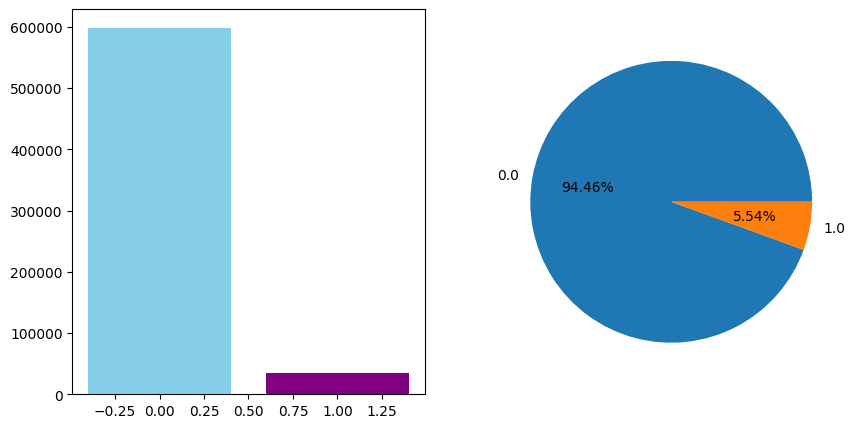

In [22]:
data=df['is_fraud'].value_counts()
fig, axes = plt.subplots(1,2,figsize=(10,5))
axes[0].bar(data.index,data,color=['skyblue','purple'])
axes[1].pie(data,labels=data.index,autopct='%1.2f%%')
plt.show()

FRAUD ASSOCIATED WITH COUNTRY

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Australia'),
  Text(1, 0, 'Brazil'),
  Text(2, 0, 'Canada'),
  Text(3, 0, 'France'),
  Text(4, 0, 'Germany'),
  Text(5, 0, 'India'),
  Text(6, 0, 'Japan'),
  Text(7, 0, 'Mexico'),
  Text(8, 0, 'UK'),
  Text(9, 0, 'USA')])

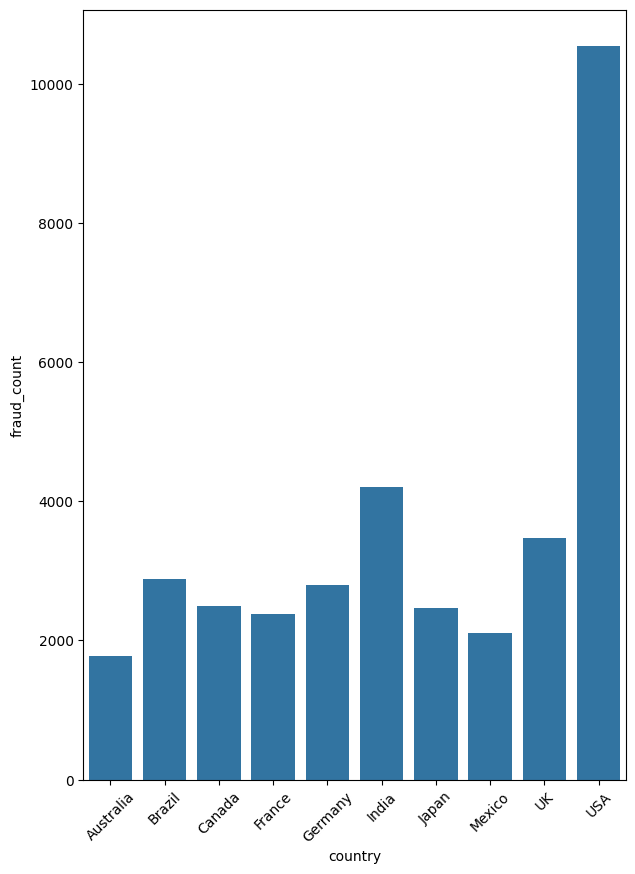

In [23]:
country_fraud =  (df[df['is_fraud'] == 1]
    .groupby('country')
    .size()
    .reset_index(name='fraud_count')
)
# country_fraud

plt.figure(figsize=(7,10))
sns.barplot(x='country', y='fraud_count', data=country_fraud)
plt.xticks(rotation=45)

FRAUD ASSOCIATED WITH AGE

(array([10., 20., 30., 40., 50., 60., 70., 80., 90.]),
 [Text(10.0, 0, '10'),
  Text(20.0, 0, '20'),
  Text(30.0, 0, '30'),
  Text(40.0, 0, '40'),
  Text(50.0, 0, '50'),
  Text(60.0, 0, '60'),
  Text(70.0, 0, '70'),
  Text(80.0, 0, '80'),
  Text(90.0, 0, '90')])

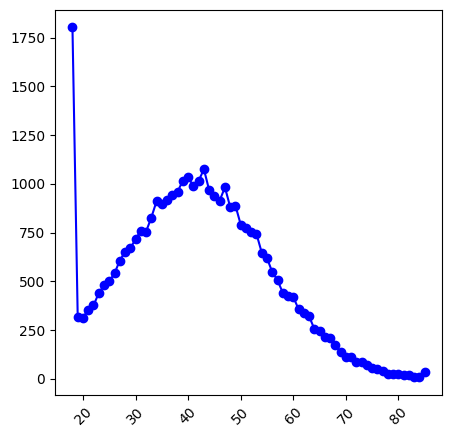

In [31]:

fraud_age=(df[df['is_fraud']==1]
             .groupby('customer_age')
             .size()
             .reset_index(name='fraud_prone_age')
)
# fraud_age

plt.figure(figsize=(5,5))
plt.plot('customer_age','fraud_prone_age',data=fraud_age,marker='o',color='BLUE')
plt.xticks(rotation=45)

FRAUD ASSOCIATED WITH CHANNEL

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Bank Transfer'),
  Text(1, 0, 'Cheque'),
  Text(2, 0, 'Credit Card'),
  Text(3, 0, 'Crypto'),
  Text(4, 0, 'Debit Card'),
  Text(5, 0, 'Mobile Payment')])

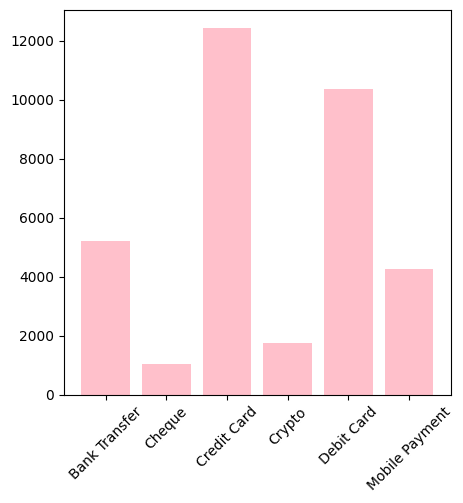

In [25]:

fraud_channel=(df[df['is_fraud']==1]
              .groupby('payment_method')
              .size()
              .reset_index(name='fraud_prone_channel')
)
# fraud_channel

plt.figure(figsize=(5,5))
plt.bar('payment_method','fraud_prone_channel',data=fraud_channel,color='pink')
plt.xticks(rotation=45)

INTERNATIONAL FRAUD DISTRIBUTION

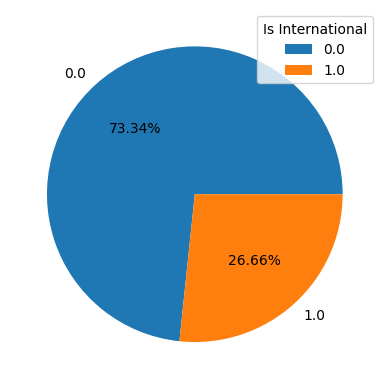

In [39]:
international_transaction=(df[df['is_fraud']==1]
                           .groupby('is_international')
                           .size()
                           .reset_index(name='international_transaction')
)
plt.pie(international_transaction['international_transaction'],labels=international_transaction['is_international'], autopct='%1.2f%%')
plt.legend(international_transaction['is_international'], title="Is International")
plt.show()